In [1]:
import glob

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import xarray as xr
import xcdat as xc
import cmocean
import geopandas as gpd
import regionmask

Matplotlib is building the font cache; this may take a moment.


## Mask

In [2]:
aus_shape = gpd.read_file(
    '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp',
    crs="epsg:4326"
)

def clip_data(da):
    """Clip data"""

    region = regionmask.from_geopandas(
        aus_shape,
        names='AUS_NAME21',
        abbrevs='AUS_CODE21',
        name='country',
    )
    mask = region.mask_3D(da)
    mask = mask.isel(region=(mask.abbrevs=='AUS'))
    mask = mask.squeeze()
    da_clipped = da.where(mask)
    
    return da_clipped

/g/data/xv83/dbi599/miniconda3/envs/npcp4/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option CRS
  return ogr_read(


In [3]:
fraction_dir = '/g/data/ia39/npcp/data/pr/observations/AGCD/raw/task-reference/'
fraction_file = 'pr-weights_r005_AGCD_v1-0-1_day_19600101-20221231.nc'
ds_fraction = xr.open_dataset(fraction_dir+fraction_file)
da_fraction = ds_fraction['fraction']
    
def mask_by_pr_ob_fraction(da, threshold=0.9):
    """Mask data according to precip obs fraction"""
    
    da_selection = da_fraction > threshold 
    da = da.where(da_selection)
    da = clip_data(da)
    
    return da

## AGCD

In [4]:
agcd_files = sorted(glob.glob('/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_*_daily.nc'))

In [5]:
ds_agcd = xr.open_mfdataset(agcd_files[60:-2])

/jobfs/166561284.gadi-pbs/ipykernel_696468/4263086412.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_agcd = xr.open_mfdataset(agcd_files[60:-2])


In [6]:
da_agcd_annual = ds_agcd['precip'].resample(time='YE').sum('time', skipna=True, keep_attrs=True)
da_agcd_annual = da_agcd_annual.compute()

In [7]:
da_agcd_clim = da_agcd_annual.mean(dim='time').compute()

In [8]:
da_agcd_clim = mask_by_pr_ob_fraction(da_agcd_clim)

## Model data

In [9]:
gcm_dict = {}
gcm_dict['BARPA-R'] = [
    'ACCESS-CM2',
    'ACCESS-ESM1-5',
    'CESM2',
    'CMCC-ESM2',
    'EC-Earth3',
    'MPI-ESM1-2-HR',
    'NorESM2-MM',
]
gcm_dict['CCAM-v2203-SN'] = [
    'ACCESS-CM2',
    'ACCESS-ESM1-5',
    'CESM2',
    'CMCC-ESM2',
    'CNRM-ESM2-1',
    'EC-Earth3',
    'NorESM2-MM',
]

In [10]:
def get_infiles(rcm, gcm, bc):
    """Get infiles"""

    assert bc in ['QME', 'MRNBC', 'raw']

    if bc == 'raw':
        activity = 'DD'
        var = 'pr'
        version = 'v1-r1'
    else:
        activity = 'bias-adjusted-output'
        var = 'prAdjust'
        version = f'v1-r1-ACS-{bc}-AGCDv1-1960-2022'

    file_list = [
        glob.glob(f'/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/{activity}/AUST-05i/*/{gcm}/historical/*/{rcm}/{version}/yr/{var}/v20241216/*.nc')[0],
        glob.glob(f'/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/{activity}/AUST-05i/*/{gcm}/ssp370/*/{rcm}/{version}/yr/{var}/v20241216/*.nc')[0],
    ]

    return file_list, var

In [11]:
def climatology(rcm, gcm, bc):
    """Calculate the 1960-2022 climatology."""

    file_list, var = get_infiles(rcm, gcm, bc)
    ds = xr.open_mfdataset(file_list)
    da_clim = ds[var].sel(time=slice('1960-01-01', '2022-12-31')).mean(dim='time').compute()
    da_clim = mask_by_pr_ob_fraction(da_clim)

    return da_clim

In [12]:
def calc_diff(model_data):
    """Calculate difference between model and obs"""

    diff_raw = model_data - da_agcd_clim 
    diff_pct = (diff_raw / da_agcd_clim) * 100

    return diff_raw, diff_pct

In [13]:
clim_dict = {}
diff_dict = {}
diff_dict_pct = {}
for rcm in ['BARPA-R', 'CCAM-v2203-SN']:
    for gcm in gcm_dict[rcm]:
        for bc in ['raw', 'QME', 'MRNBC']:
            key = (rcm, gcm, bc)
            print(key)
            clim_dict[key] = climatology(rcm, gcm, bc)
            diff_dict[key], diff_dict_pct[key] = calc_diff(clim_dict[key])

('BARPA-R', 'ACCESS-CM2', 'raw')
('BARPA-R', 'ACCESS-CM2', 'QME')
('BARPA-R', 'ACCESS-CM2', 'MRNBC')
('BARPA-R', 'ACCESS-ESM1-5', 'raw')
('BARPA-R', 'ACCESS-ESM1-5', 'QME')
('BARPA-R', 'ACCESS-ESM1-5', 'MRNBC')
('BARPA-R', 'CESM2', 'raw')
('BARPA-R', 'CESM2', 'QME')
('BARPA-R', 'CESM2', 'MRNBC')
('BARPA-R', 'CMCC-ESM2', 'raw')
('BARPA-R', 'CMCC-ESM2', 'QME')
('BARPA-R', 'CMCC-ESM2', 'MRNBC')
('BARPA-R', 'EC-Earth3', 'raw')
('BARPA-R', 'EC-Earth3', 'QME')
('BARPA-R', 'EC-Earth3', 'MRNBC')
('BARPA-R', 'MPI-ESM1-2-HR', 'raw')
('BARPA-R', 'MPI-ESM1-2-HR', 'QME')
('BARPA-R', 'MPI-ESM1-2-HR', 'MRNBC')
('BARPA-R', 'NorESM2-MM', 'raw')
('BARPA-R', 'NorESM2-MM', 'QME')
('BARPA-R', 'NorESM2-MM', 'MRNBC')
('CCAM-v2203-SN', 'ACCESS-CM2', 'raw')
('CCAM-v2203-SN', 'ACCESS-CM2', 'QME')
('CCAM-v2203-SN', 'ACCESS-CM2', 'MRNBC')
('CCAM-v2203-SN', 'ACCESS-ESM1-5', 'raw')
('CCAM-v2203-SN', 'ACCESS-ESM1-5', 'QME')
('CCAM-v2203-SN', 'ACCESS-ESM1-5', 'MRNBC')
('CCAM-v2203-SN', 'CESM2', 'raw')
('CCAM-v2203-SN

In [14]:
def plot_row(row_axes, rcm, gcm, units, region='AUS', point=None):
    """Plot row"""

    if units == 'mm':
        diffs = diff_dict
        levels = [-220, -180, -140, -100, -60, -20, 20 , 60, 100, 140, 180, 220]
    elif units == '%':
        diffs = diff_dict_pct
        levels = [-20, -10, -6, -2, 2, 6, 10, 20]
    else:
        raise ValueError(f'Unrecognised units {units}')

    if region == 'WA':
        extent = [112.5, 130, -13.2, -35.3]
    else:
        extent = None
    
    ax1, ax2, ax3 = row_axes
    
    im1 = diffs[(rcm, gcm, 'raw')].plot(
        ax=ax1,
        transform=ccrs.PlateCarree(),
        cmap='BrBG',
        levels=levels,
        cbar_kwargs={'label': f'difference ({units})'},
        extend='both',
    )
    ax1.coastlines()
    ax1.add_feature(cartopy.feature.STATES)
    ax1.set_title(gcm)
    if extent:
        ax1.set_extent(extent, crs=ccrs.PlateCarree())

    im2 = diffs[(rcm, gcm, 'QME')].plot(
        ax=ax2,
        transform=ccrs.PlateCarree(),
        cmap='BrBG',
        levels=levels,
        cbar_kwargs={'label': f'difference ({units})'},
        extend='both',
    )
    ax2.coastlines()
    ax2.add_feature(cartopy.feature.STATES)
    ax2.set_title(f'{gcm} (QME)')
    if point:
        lat, lon = point
        ax2.plot(lon, lat, color='red', marker='o', transform=ccrs.PlateCarree())
    if extent:
        ax2.set_extent(extent, crs=ccrs.PlateCarree())
    
    im3 = diffs[(rcm, gcm, 'MRNBC')].plot(
        ax=ax3,
        transform=ccrs.PlateCarree(),
        cmap='BrBG',
        levels=levels,
        cbar_kwargs={'label': f'difference ({units})'},
        extend='both',
    )
    ax3.coastlines()
    ax3.add_feature(cartopy.feature.STATES)
    ax3.set_title(f'{gcm} (MRNBC)')
    if point:
        lat, lon = point
        ax3.plot(lon, lat, color='red', marker='o', transform=ccrs.PlateCarree())
    if extent:
        ax3.set_extent(extent, crs=ccrs.PlateCarree())

In [17]:
region = 'AUS'
if region == 'WA':
    width = 10
else:
    width = 15

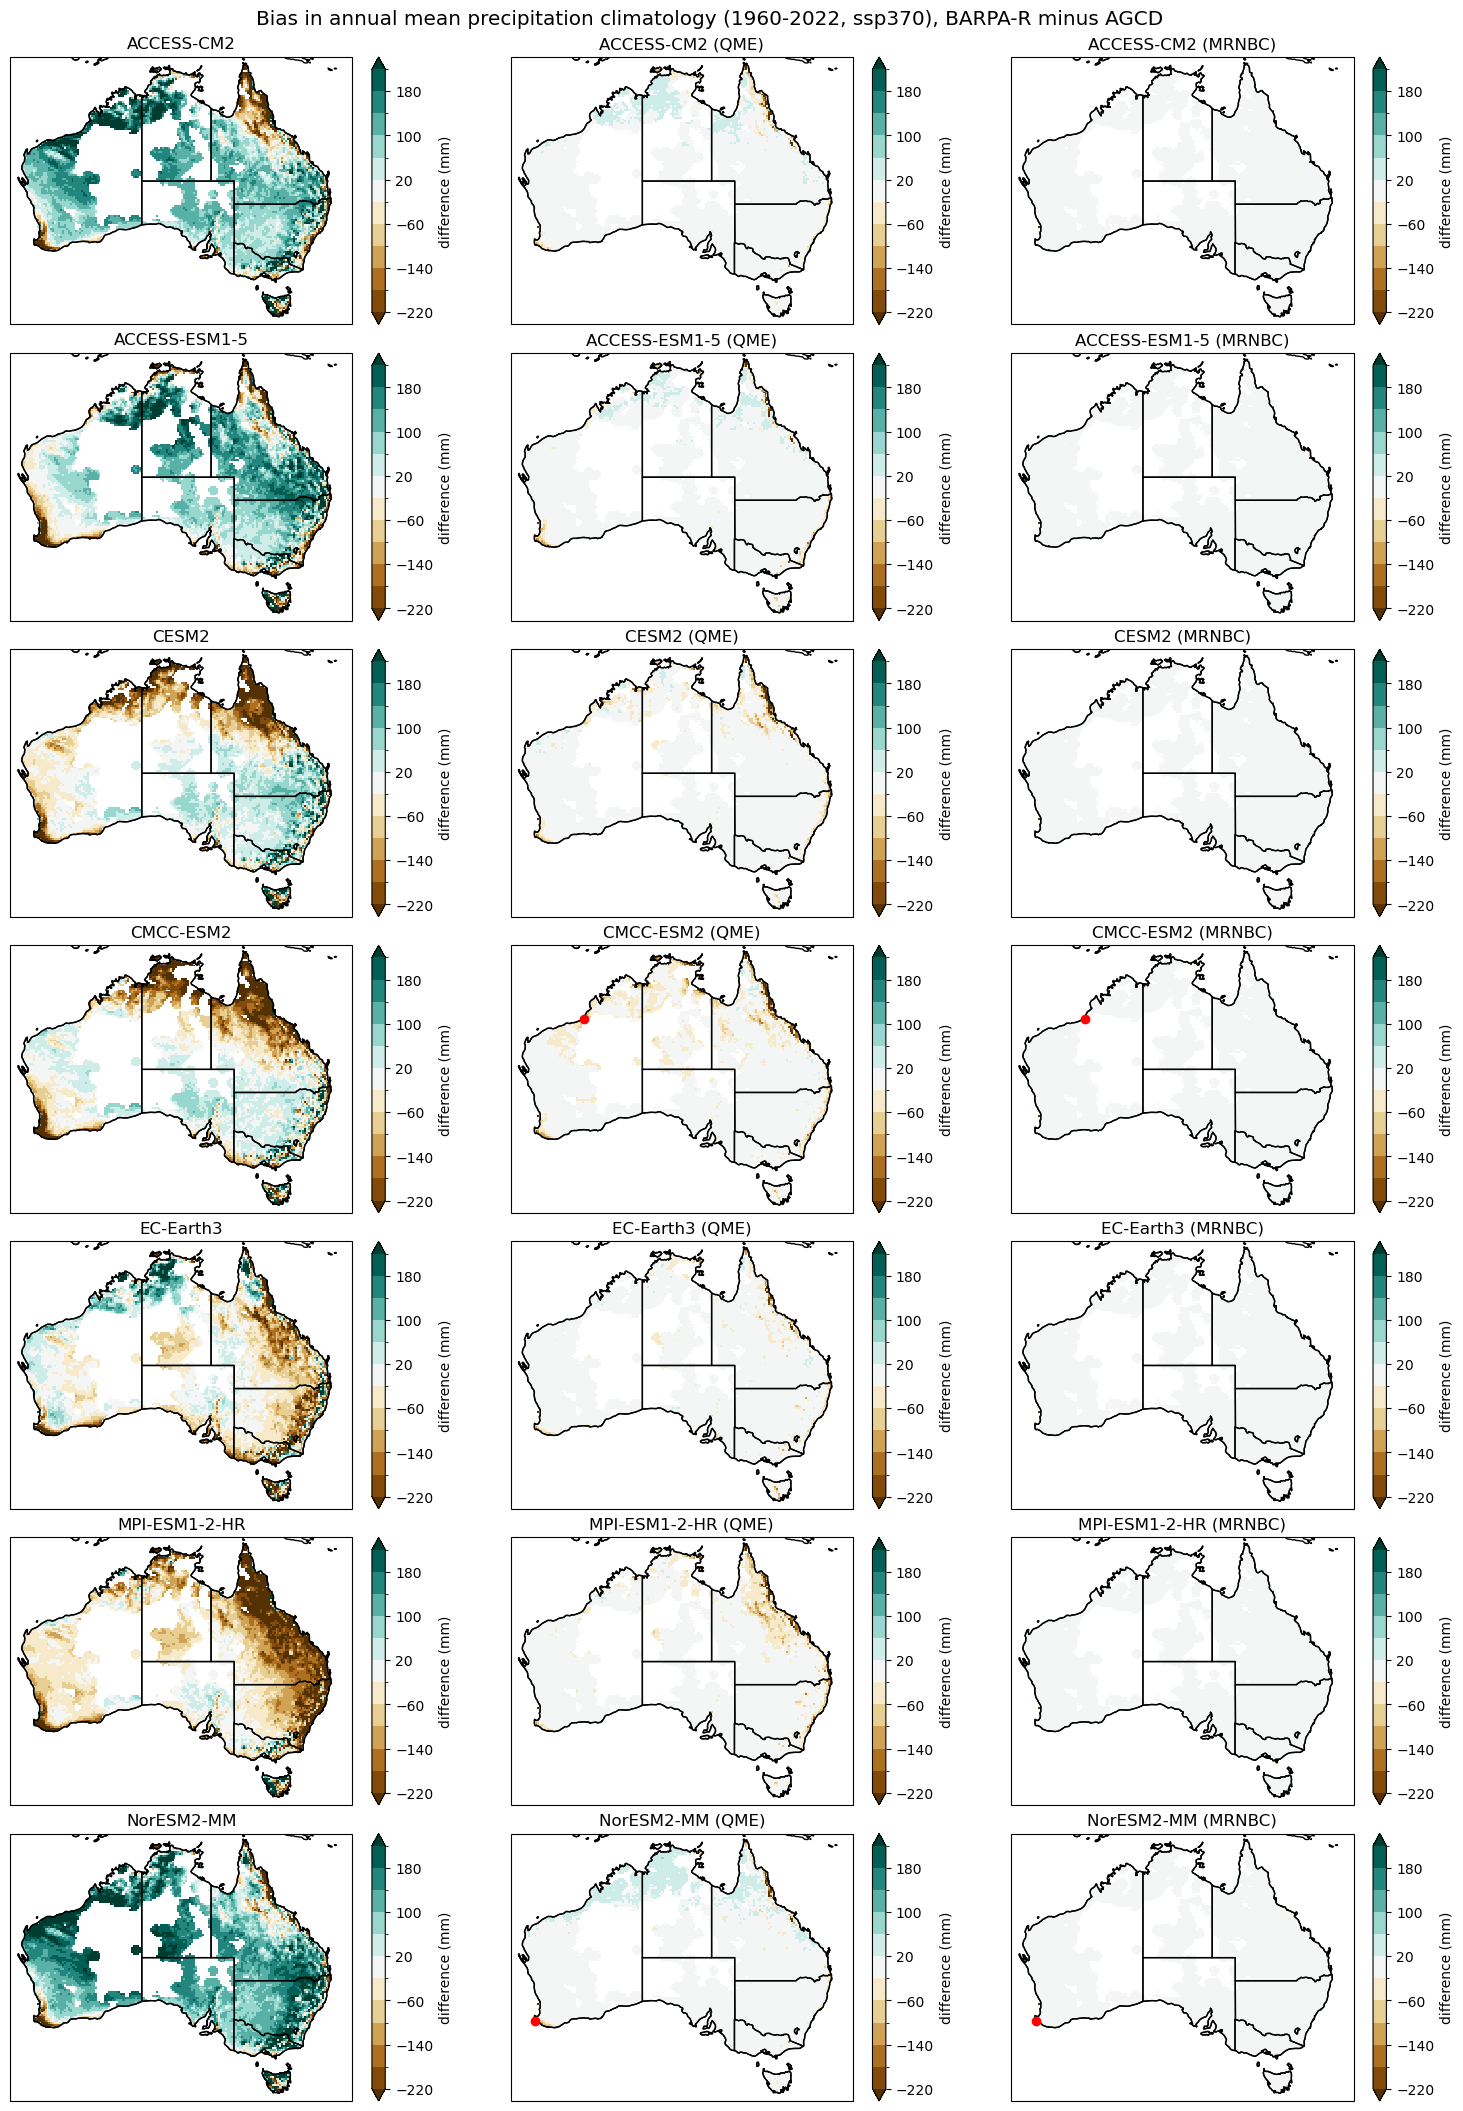

In [18]:
ngcms = 7
fig, axes = plt.subplots(ngcms, 3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[width, 3*ngcms], layout='constrained')
plot_row(axes[0, :], 'BARPA-R', 'ACCESS-CM2', units='mm', region=region)
plot_row(axes[1, :], 'BARPA-R', 'ACCESS-ESM1-5', units='mm', region=region)
plot_row(axes[2, :], 'BARPA-R', 'CESM2', units='mm', region=region)
plot_row(axes[3, :], 'BARPA-R', 'CMCC-ESM2', units='mm', region=region, point=[-19.4, 121.45])
plot_row(axes[4, :], 'BARPA-R', 'EC-Earth3', units='mm', region=region)
plot_row(axes[5, :], 'BARPA-R', 'MPI-ESM1-2-HR', units='mm', region=region)
plot_row(axes[6, :], 'BARPA-R', 'NorESM2-MM', units='mm', region=region, point=[-34.2, 115.1])
plt.suptitle('Bias in annual mean precipitation climatology (1960-2022, ssp370), BARPA-R minus AGCD', fontsize='x-large')
plt.savefig(f'pr-bias_BARPA-R_1960-2022-annual-clim_ssp370_{region}_mm.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

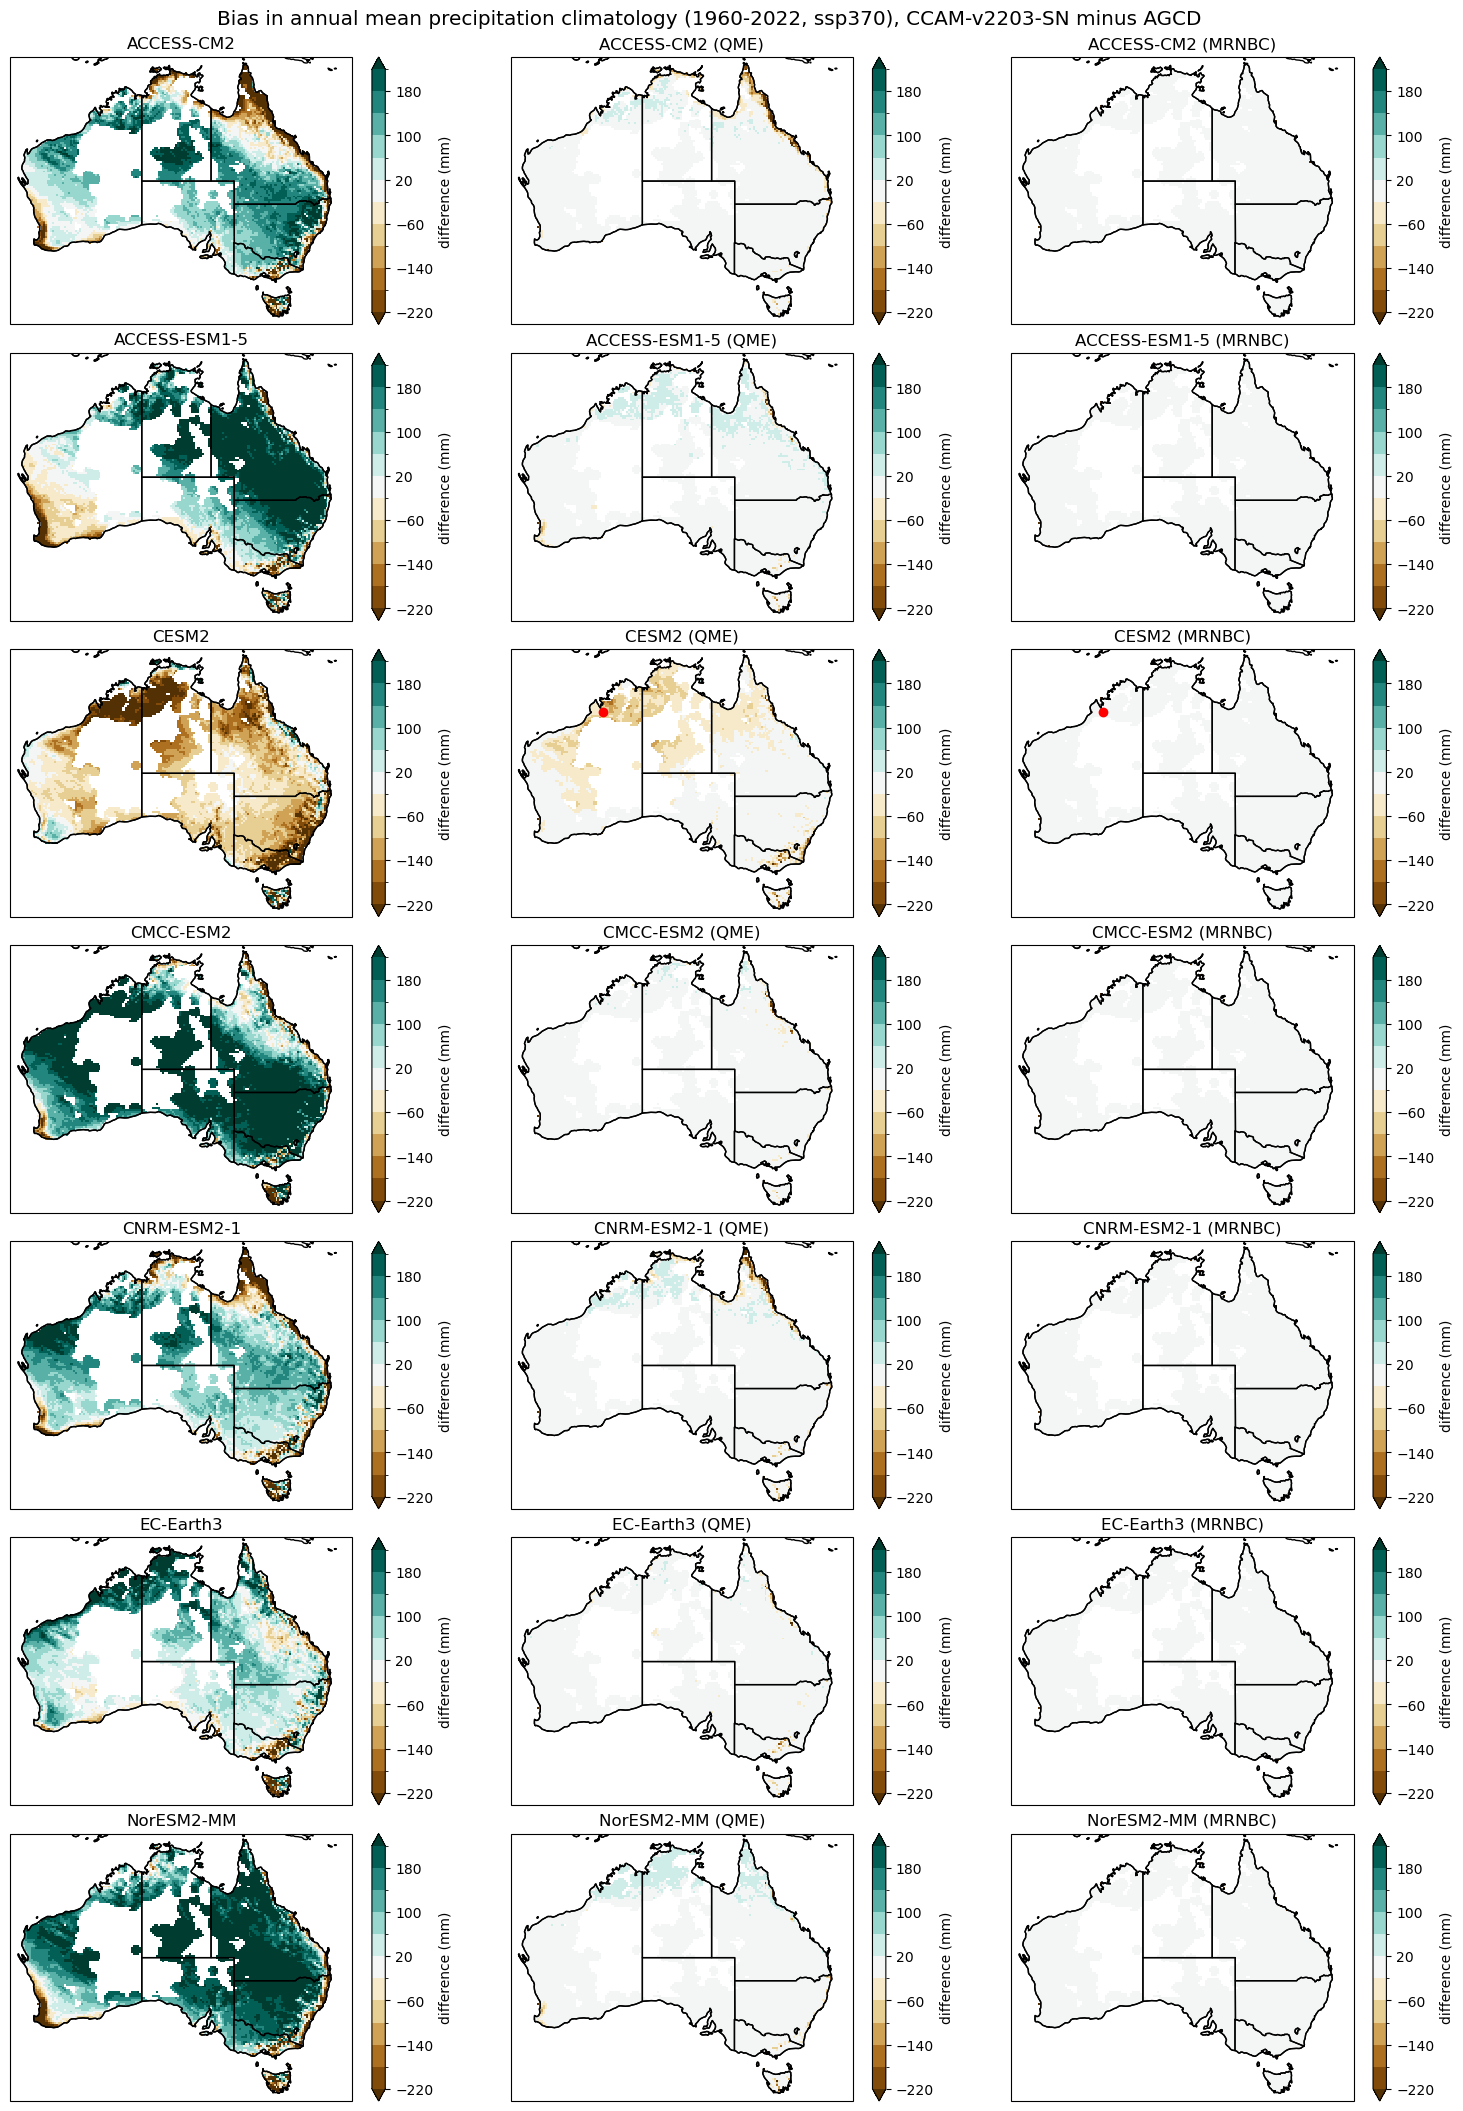

In [19]:
ngcms = 7
fig, axes = plt.subplots(ngcms, 3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[width, 3*ngcms], layout='constrained')
plot_row(axes[0, :], 'CCAM-v2203-SN', 'ACCESS-CM2', units='mm', region=region)
plot_row(axes[1, :], 'CCAM-v2203-SN', 'ACCESS-ESM1-5', units='mm', region=region)
plot_row(axes[2, :], 'CCAM-v2203-SN', 'CESM2', units='mm', region=region, point=[-18, 123.85])
plot_row(axes[3, :], 'CCAM-v2203-SN', 'CMCC-ESM2', units='mm', region=region)
plot_row(axes[4, :], 'CCAM-v2203-SN', 'CNRM-ESM2-1', units='mm', region=region)
plot_row(axes[5, :], 'CCAM-v2203-SN', 'EC-Earth3', units='mm', region=region)
plot_row(axes[6, :], 'CCAM-v2203-SN', 'NorESM2-MM', units='mm', region=region)
plt.suptitle('Bias in annual mean precipitation climatology (1960-2022, ssp370), CCAM-v2203-SN minus AGCD', fontsize='x-large')
plt.savefig(f'pr-bias_CCAM-v2203-SN_1960-2022-annual-clim_ssp370_{region}_mm.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

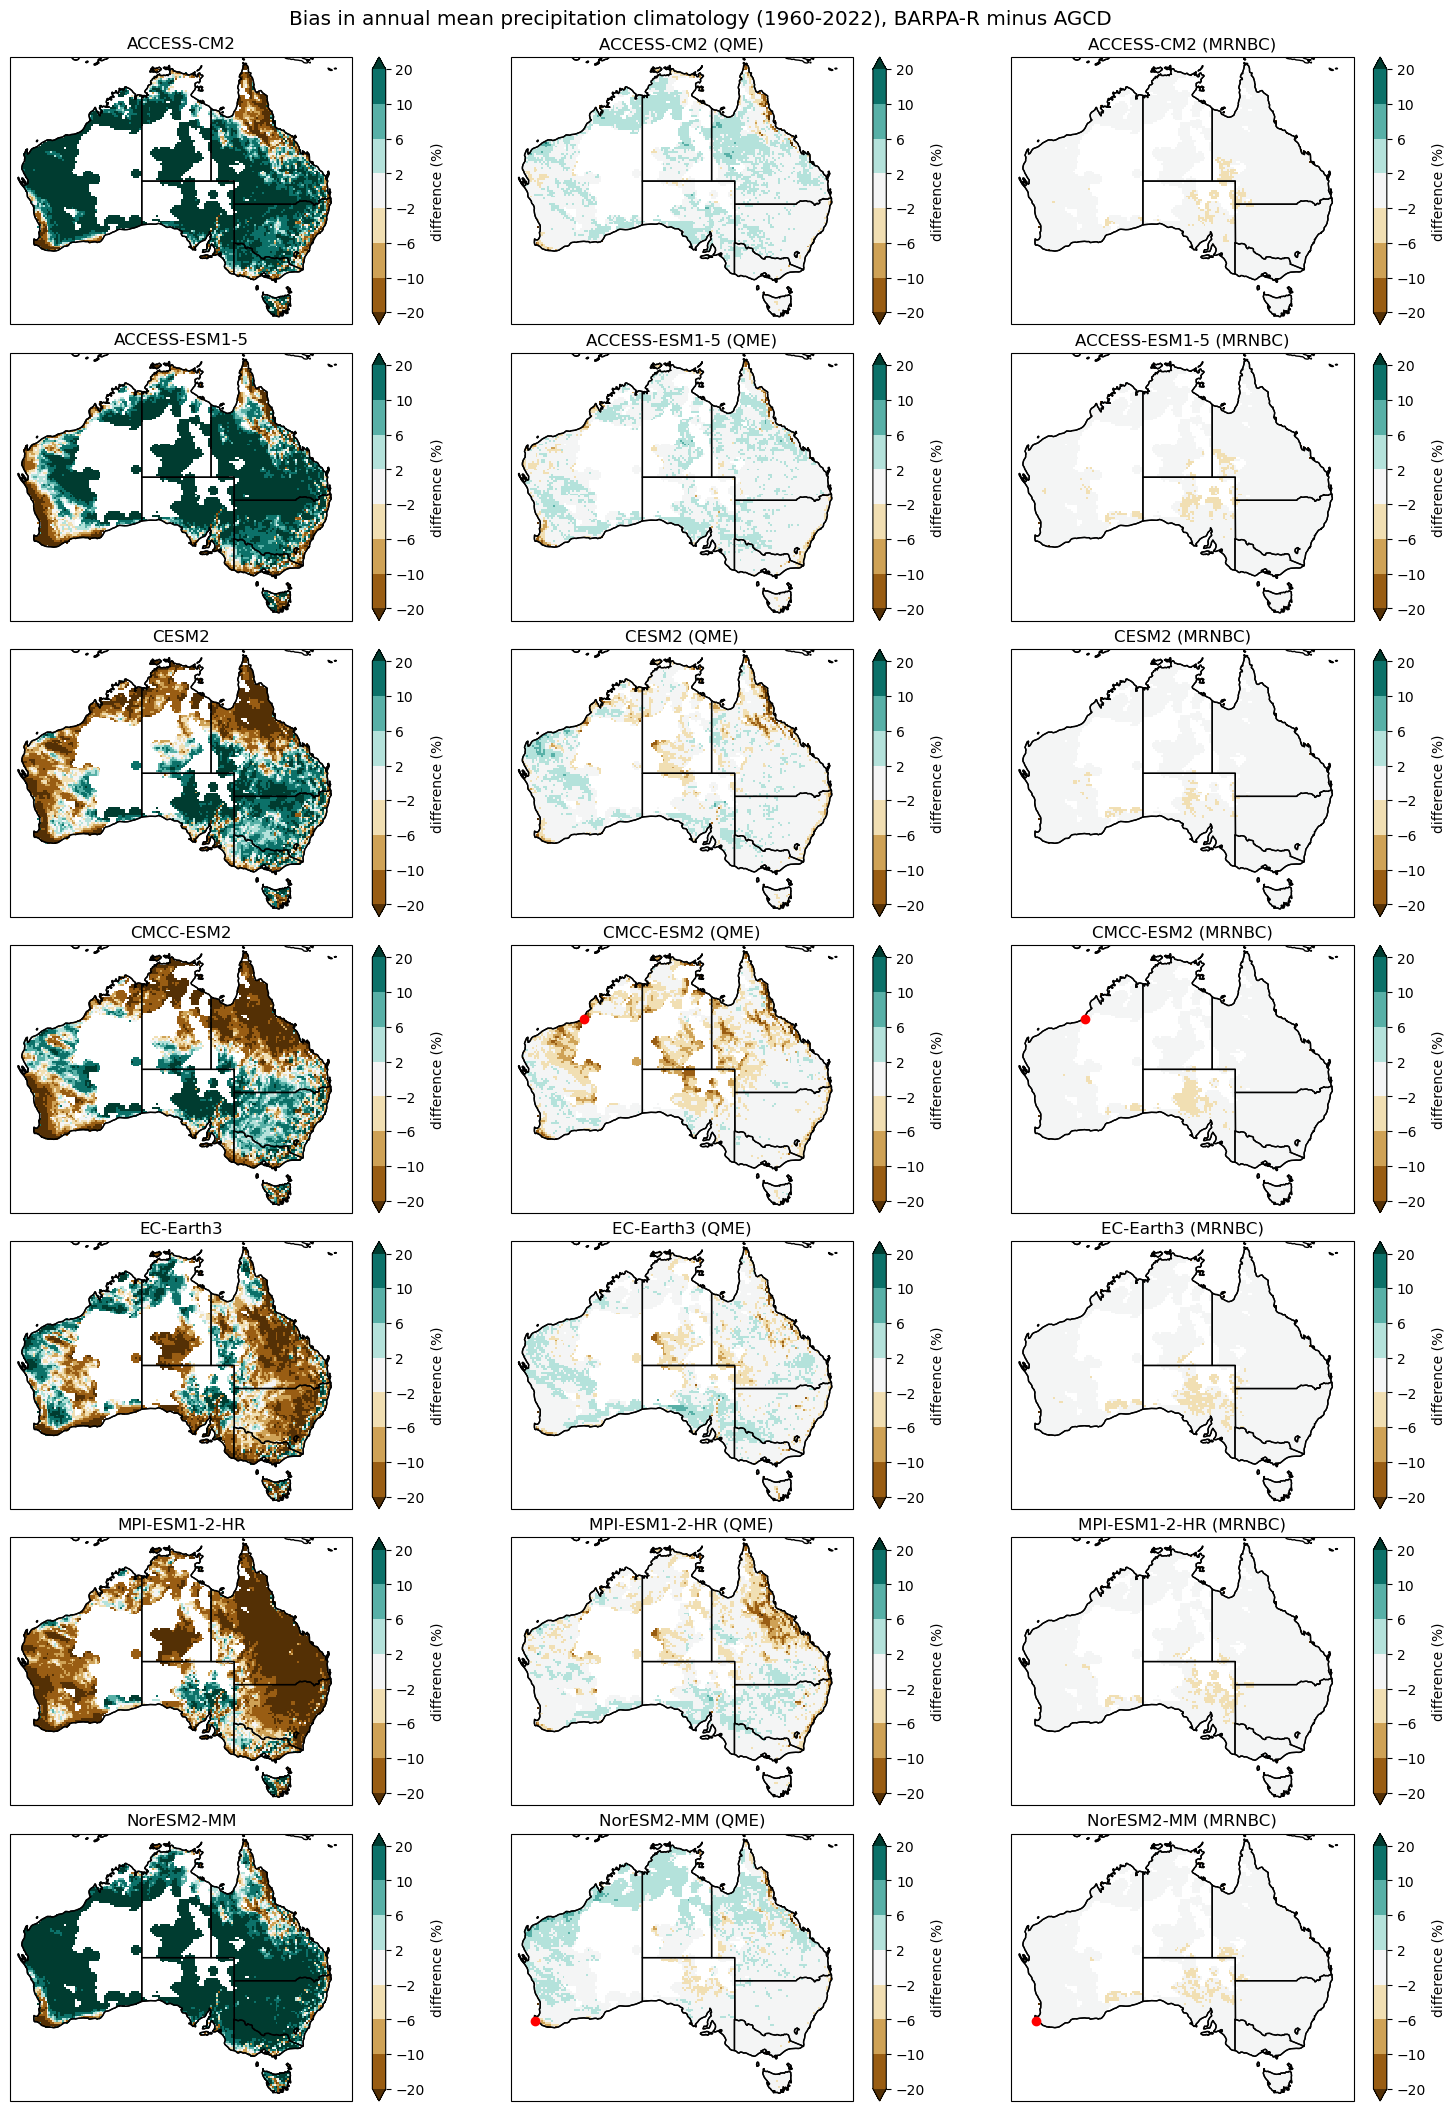

In [20]:
ngcms = 7
fig, axes = plt.subplots(ngcms, 3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[width, 3*ngcms], layout='constrained')
plot_row(axes[0, :], 'BARPA-R', 'ACCESS-CM2', units='%', region=region)
plot_row(axes[1, :], 'BARPA-R', 'ACCESS-ESM1-5', units='%', region=region)
plot_row(axes[2, :], 'BARPA-R', 'CESM2', units='%', region=region)
plot_row(axes[3, :], 'BARPA-R', 'CMCC-ESM2', units='%', region=region, point=[-19.4, 121.45])
plot_row(axes[4, :], 'BARPA-R', 'EC-Earth3', units='%', region=region)
plot_row(axes[5, :], 'BARPA-R', 'MPI-ESM1-2-HR', units='%', region=region)
plot_row(axes[6, :], 'BARPA-R', 'NorESM2-MM', units='%', region=region, point=[-34.2, 115.1])
plt.suptitle('Bias in annual mean precipitation climatology (1960-2022), BARPA-R minus AGCD', fontsize='x-large')
plt.savefig(f'pr-bias_BARPA-R_1960-2022-annual-clim_ssp370_{region}_pct.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

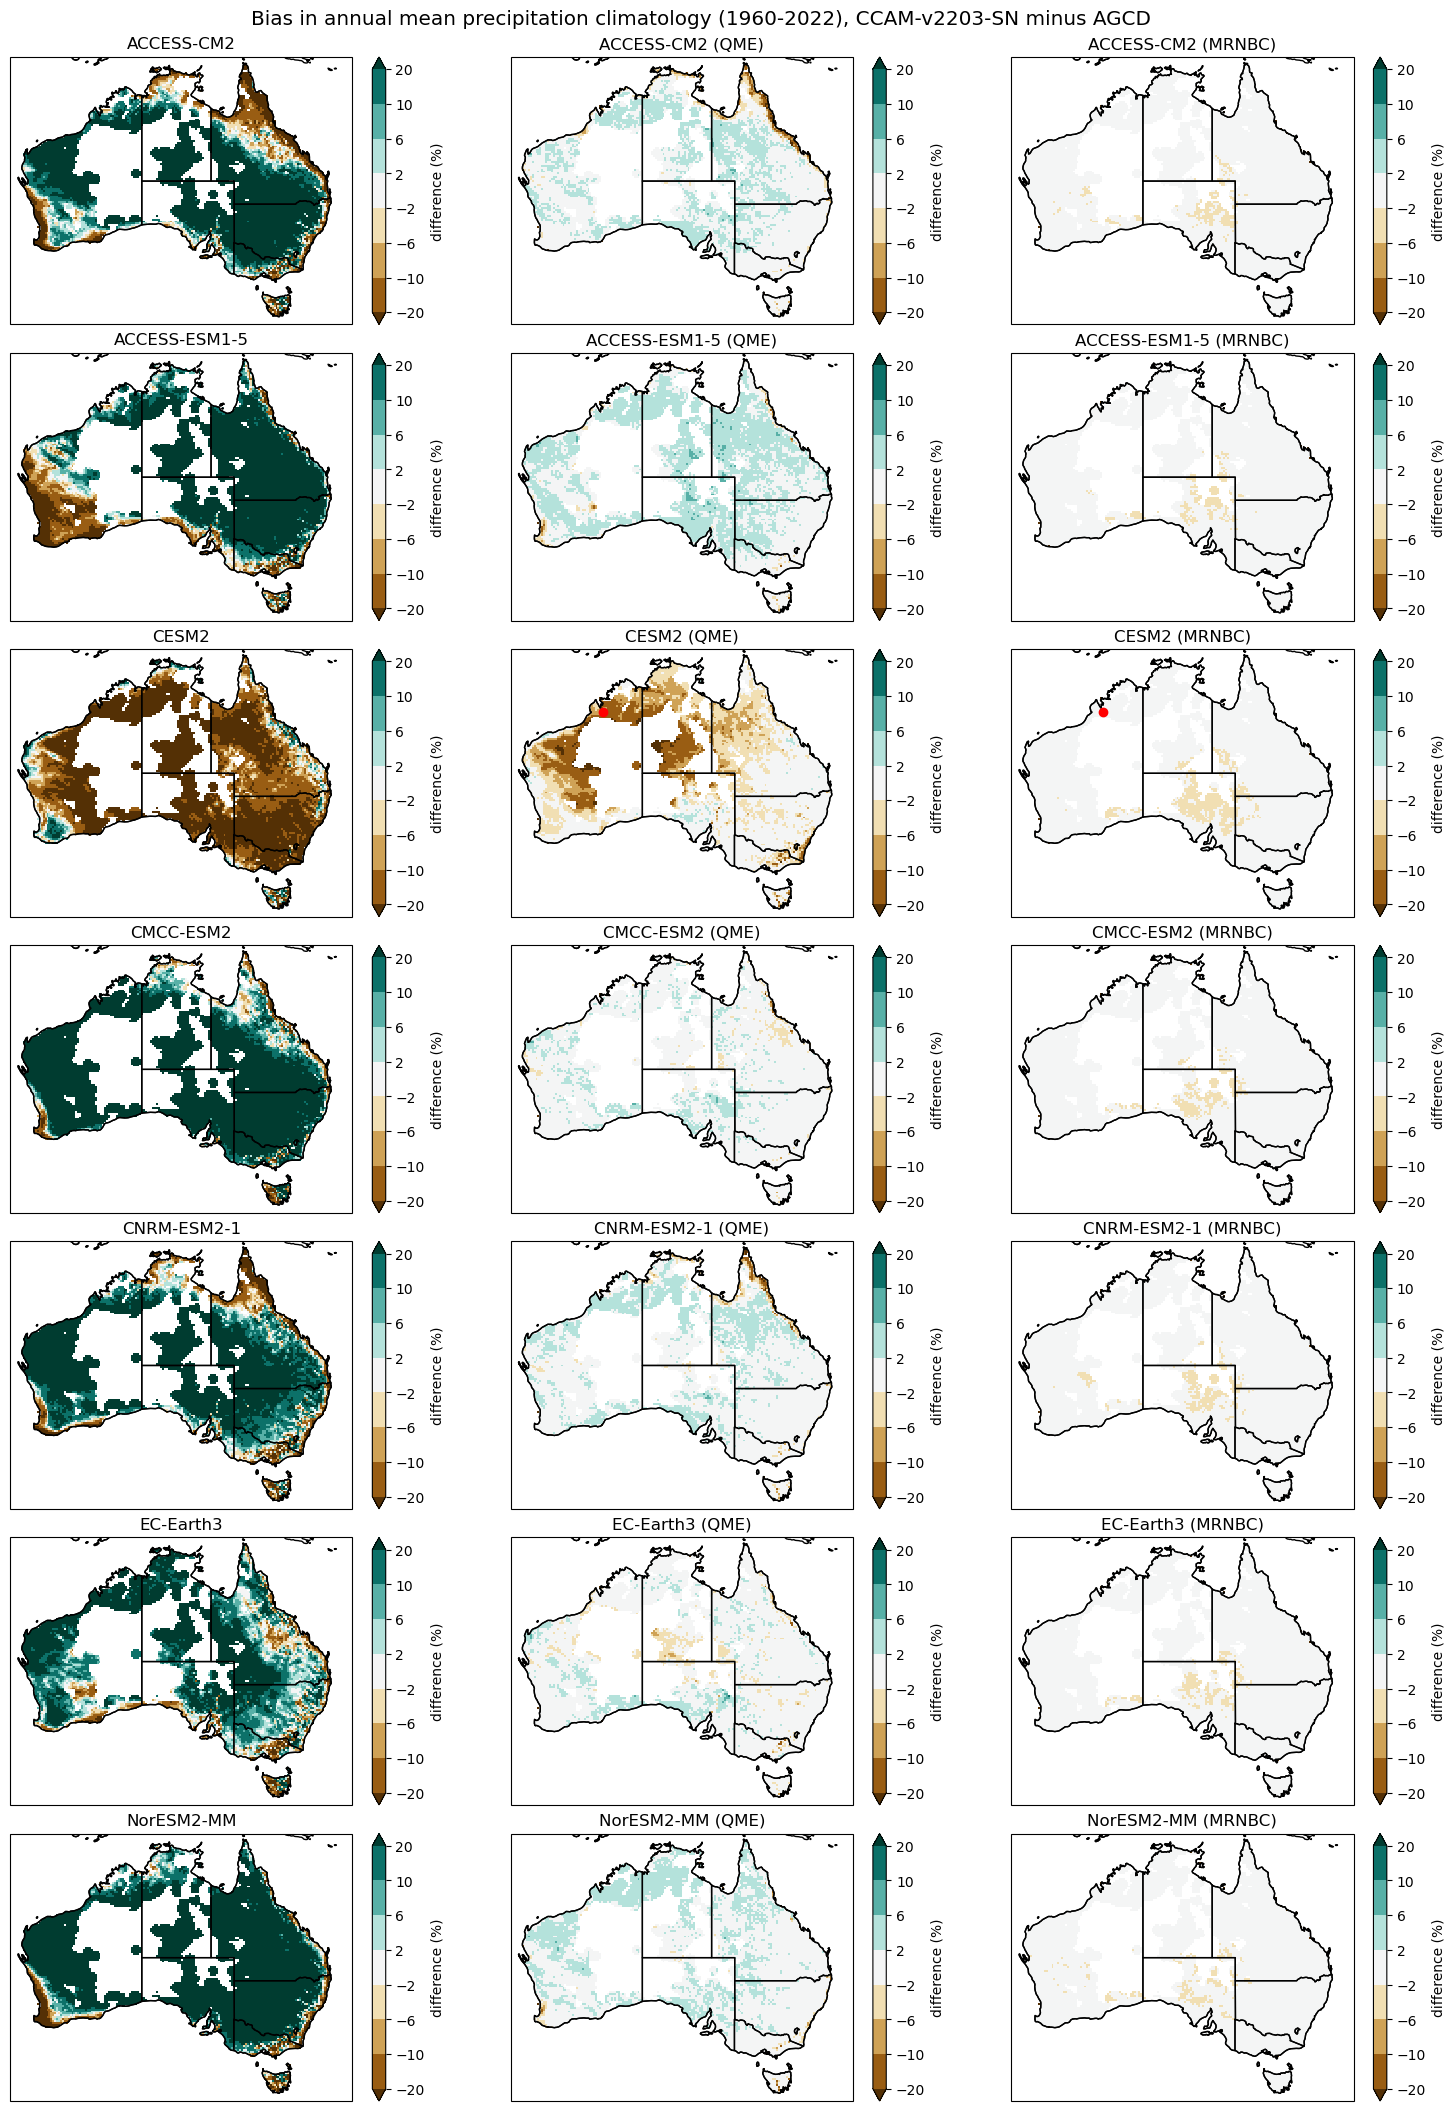

In [21]:
ngcms = 7
fig, axes = plt.subplots(ngcms, 3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[width, 3*ngcms], layout='constrained')
plot_row(axes[0, :], 'CCAM-v2203-SN', 'ACCESS-CM2', units='%', region=region)
plot_row(axes[1, :], 'CCAM-v2203-SN', 'ACCESS-ESM1-5', units='%', region=region)
plot_row(axes[2, :], 'CCAM-v2203-SN', 'CESM2', units='%', region=region, point=[-18, 123.85])
plot_row(axes[3, :], 'CCAM-v2203-SN', 'CMCC-ESM2', units='%', region=region)
plot_row(axes[4, :], 'CCAM-v2203-SN', 'CNRM-ESM2-1', units='%', region=region)
plot_row(axes[5, :], 'CCAM-v2203-SN', 'EC-Earth3', units='%', region=region)
plot_row(axes[6, :], 'CCAM-v2203-SN', 'NorESM2-MM', units='%', region=region)
plt.suptitle('Bias in annual mean precipitation climatology (1960-2022), CCAM-v2203-SN minus AGCD', fontsize='x-large')
plt.savefig(f'pr-bias_CCAM-v2203-SN_1960-2022-annual-clim_ssp370_{region}_pct.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

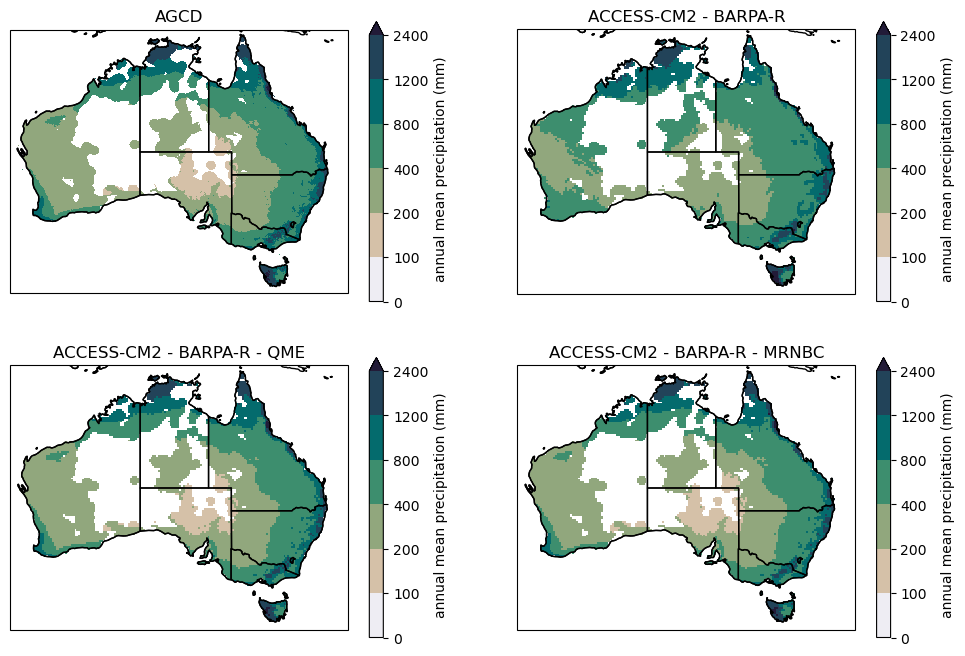

In [20]:
fig = plt.figure(figsize=[12, 8])

levels_clim = [0, 100, 200, 400, 800, 1200, 2400]

ax1 = fig.add_subplot(221, projection=ccrs.PlateCarree())
im1 = clim_dict['AGCD'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_title('AGCD')

ax2 = fig.add_subplot(222, projection=ccrs.PlateCarree())
im2 = clim_dict['raw'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
ax2.set_title('ACCESS-CM2 - BARPA-R')

ax3 = fig.add_subplot(223, projection=ccrs.PlateCarree())
im3 = clim_dict['QME'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
ax3.set_title('ACCESS-CM2 - BARPA-R - QME')

ax4 = fig.add_subplot(224, projection=ccrs.PlateCarree())
im4 = clim_dict['MRNBC'].plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax4.coastlines()
ax4.add_feature(cartopy.feature.STATES)
ax4.set_title('ACCESS-CM2 - BARPA-R - MRNBC')

plt.show()